In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.special import erf

from jax import config
config.update("jax_enable_x64", True)

In [3]:
units_num = 40

In [4]:
t0, tfinal = 0.0, 0.5

In [5]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [6]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [7]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [8]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [9]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [10]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    

    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:4]
    H_0 = u[:, 4:]

    u = u[:, :4]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [11]:
deeponet = DeepONet(t0, tfinal, layers=4, units=units_num)

params = deeponet.init(jax.random.PRNGKey(0), jnp.ones((10,)), jnp.ones((10,4)))

In [12]:
def defineCollocationPoints(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  xs = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))
  ys = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))

  zsensors = np.column_stack((xs, ys))

  return (ode_points, zsensors)

In [13]:
def CdefineCollocationPoints(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    x1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    x2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    y1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    y2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    Hs = (m2*l2**2*y1s**2 + (m1+m2)*l1**2*y2s**2 - 2*m2*l1*l2*y1s*y2s*np.cos(x1s-x2s))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1s-x2s)**2))-(m1+m2)*grav*l1*np.cos(x1s)-m2*grav*l2*np.cos(x2s)
 
    zsensors = np.column_stack((x1s, x2s, y1s, y2s, Hs))
    
    return (ode_points, zsensors)

In [14]:
(de_points, zsensors) = CdefineCollocationPoints([t0, tfinal], 1000)

print(de_points.shape, zsensors.shape)

(1000, 1) (1000, 5)


In [15]:
@partial(jax.jit, static_argnums=(2,))
def w_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def w(t, z, component, params):
  return jax.vmap(w_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def w_t(t, z, component, params):
  return jax.vmap(jax.grad(w_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    diff_loss_w = 1.0
    H_loss_w = 1.0

    H_vals = z[:, -1]

    x1 = w(t, z, 0, params)
    x2 = w(t, z, 1, params)
    y1 = w(t, z, 2, params)
    y2 = w(t, z, 3, params)
    
    x1_t = w_t(t, z, 0, params)
    x2_t = w_t(t, z, 1, params)
    y1_t = w_t(t, z, 2, params)
    y2_t = w_t(t, z, 3, params)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)
 
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    H_loss = jnp.mean((H - H_vals)**2)

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [16]:
def train_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.yogi(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [17]:
epochs = 1000
params, loss = train_network(params, de_points, zsensors, epochs)

Loss in epoch 0: 3.2908763769032374
Loss in epoch 100: 0.014270471173174459
Loss in epoch 200: 0.010086362814658596
Loss in epoch 300: 0.008430918162562084
Loss in epoch 400: 0.004736021635733242
Loss in epoch 500: 0.0031601354205559934
Loss in epoch 600: 0.0022521833872319137
Loss in epoch 700: 0.0018686338375592268
Loss in epoch 800: 0.001488966927581713
Loss in epoch 900: 0.0012921544984640643


In [18]:
loss_adam = loss

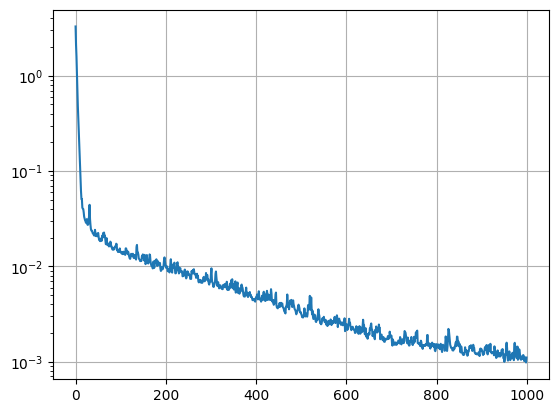

In [19]:
plt.semilogy(loss_adam)
plt.grid()

In [20]:
n = 500
t = np.linspace(t0, tfinal, n)

x1_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y1_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y2_data = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
H_data = (m2*l2**2*y1_data**2 + (m1+m2)*l1**2*y2_data**2 - 2*m2*l1*l2*y1_data*y2_data*np.cos(x1_data-x2_data))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_data-x2_data)**2))-(m1+m2)*grav*l1*np.cos(x1_data)-m2*grav*l2*np.cos(x2_data)

init_data = np.column_stack([x1_data, x2_data, y1_data, y2_data])
init_data_H = np.column_stack([x1_data, x2_data, y1_data, y2_data, H_data])

init_data = np.reshape(init_data, (-1,))
init_data_H = np.reshape(init_data_H, (-1,))

z_init = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)
z_init_H = np.repeat(np.expand_dims(init_data_H, axis=0), len(t), axis=0)

print(init_data.shape, z_init.shape)
print(init_data_H.shape, z_init_H.shape)

(4,) (500, 4)
(5,) (500, 5)


In [21]:
x1 = jax.vmap(w_model, [0, 0, None, None])(t, z_init_H, 0, params)
x2 = jax.vmap(w_model, [0, 0, None, None])(t, z_init_H, 1, params)
y1 = jax.vmap(w_model, [0, 0, None, None])(t, z_init_H, 2, params)
y2 = jax.vmap(w_model, [0, 0, None, None])(t, z_init_H, 3, params)

H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*np.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1-x2)**2))-(m1+m2)*grav*l1*np.cos(x1)-m2*grav*l2*np.cos(x2)

z_H = jnp.column_stack([x1, x2, y1, y2, H])

print(z_H.shape)

(500, 5)


In [22]:
def doublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

sol_rk = odeint(doublePendulum, init_data, t, rtol = 1e-13, atol = 1e-13)
x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]
Hrk = (m2*l2**2*y1rk**2 + (m1+m2)*l1**2*y2rk**2 - 2*m2*l1*l2*y1rk*y2rk*np.cos(x1rk-x2rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1rk-x2rk)**2))-(m1+m2)*grav*l1*np.cos(x1rk)-m2*grav*l2*np.cos(x2rk)

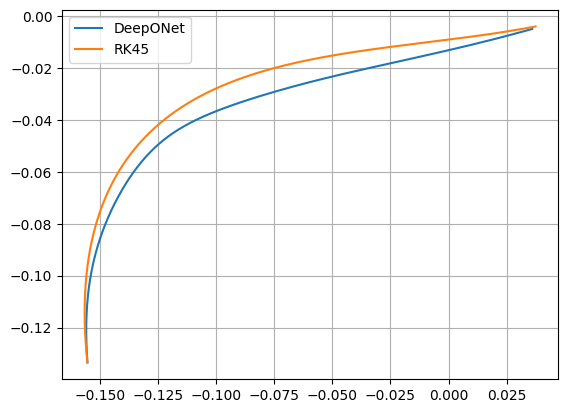

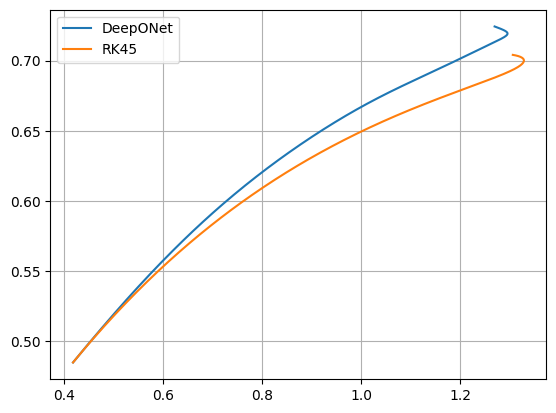

In [23]:
plt.plot(x1, x2)
plt.plot(x1rk, x2rk)

plt.grid()
plt.legend(['DeepONet','RK45'])
plt.show()

plt.plot(y1, y2)
plt.plot(y1rk, y2rk)

plt.grid()
plt.legend(['DeepONet','RK45'])
plt.show()

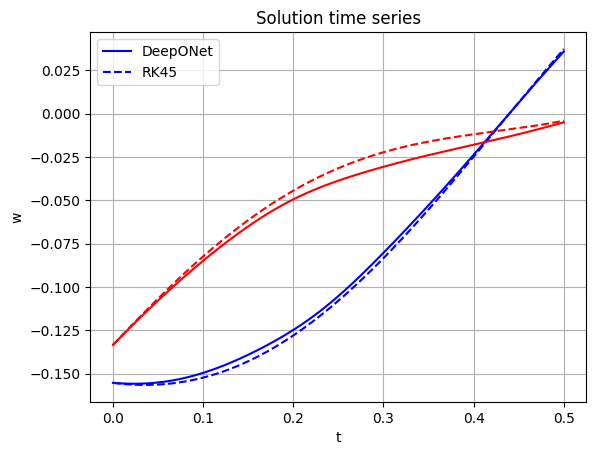

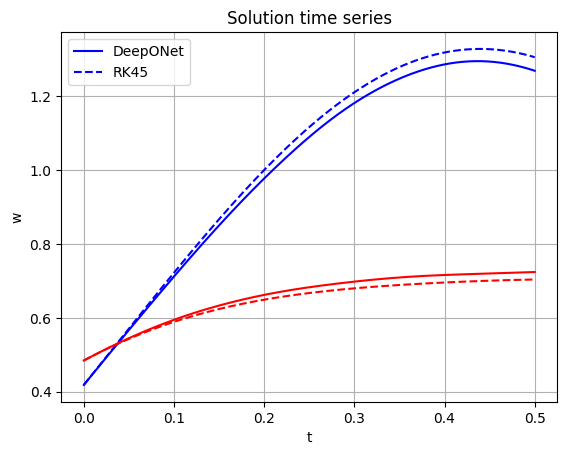

In [24]:
plt.plot(t, x1,'b')
plt.plot(t, x1rk,'b--')

plt.plot(t, x2, 'r')
plt.plot(t, x2rk, 'r--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('w')
plt.title('Solution time series')
plt.show()

plt.plot(t, y1,'b')
plt.plot(t, y1rk,'b--')

plt.plot(t, y2, 'r')
plt.plot(t, y2rk, 'r--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('w')
plt.title('Solution time series')
plt.show()

Text(0.5, 1.0, 'Hamiltonian l2-error: 0.27640')

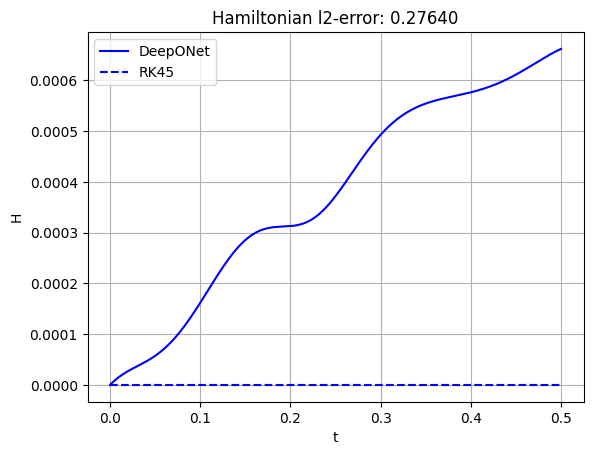

In [25]:
plt.plot(t, (H-H[0])/H[0],'b')
plt.plot(t, (Hrk-Hrk[0])/Hrk[0],'b--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('H')
plt.title(f'Hamiltonian l2-error: {np.linalg.norm((H-H[0])):2.5f}')

In [26]:
@jax.jit
def deriv_D(x, H_0) :

    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    dH_dx1 = (m1 + m2)*grav*l1*jnp.sin(x1) + h1 - h2*jnp.sin(2*(x1 - x2))
    dH_dx2 = m2*grav*l2*jnp.sin(x2) - h1 + h2*jnp.sin(2*(x1 - x2))
    dH_dy1 = (l2*y1 - l1*y2*jnp.cos(x1-x2))/(l1*A)
    dH_dy2 = (l1*(m1+m2)*y2 - m2*l2*y1*jnp.cos(x1-x2))/(m2*l2*A)

    dD_dx1 = 2*(H_0 - H)*-dH_dx1
    dD_dx2 = 2*(H_0 - H)*-dH_dx2
    dD_dy1 = 2*(H_0 - H)*-dH_dy1
    dD_dy2 = 2*(H_0 - H)*-dH_dy2
    
    deriv_D = jnp.array([dD_dx1, dD_dx2, dD_dy1, dD_dy2])
    deriv_D = jnp.reshape(deriv_D, (-1, 1))

    return deriv_D

In [27]:
@jax.jit
def func_D(x, H_0) :
 
    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]
   
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    D = (H_0 - H)**2
    
    return D

In [28]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    return 1/x

In [29]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter_num = args

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)
    
    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
     
    return final_bool

In [30]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter_num = args

    alpha = alpha*0.1
    iter_num = iter_num + 1
        
    next_x = curr_x + alpha*p
    next_f = func_D(next_x, H_0)
    next_grad = deriv_D(next_x, H_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter_num)

In [31]:
@jax.jit
def BFGS(x, H_0) :

    x = jnp.reshape(x, (-1,1))
    x_0 = x

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    c1 = 1e-4
    c2 = 0.9
    I_3 = jnp.identity(4, dtype = jnp.float64)
    B_0_inv = jnp.identity(4, dtype = jnp.float64)

    D_0 = func_D(x_0, H_0)
    gradD_0 = deriv_D(x_0, H_0)

    p = -(B_0_inv@gradD_0)

    next_x = x_0 + alpha*p
    next_D = func_D(next_x, H_0)
    next_gradD = deriv_D(next_x, H_0)

    init_args = (alpha, x_0, D_0, gradD_0, next_x, next_D, next_gradD, p, c1, c2, H_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p

    while iter_num < 10:

        delta_x = x_1 - x_0

        D_1 = func_D(x_1, H_0)
        gradD_1 = deriv_D(x_1, H_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        next_x = x_1 + alpha*p
        next_D = func_D(next_x, H_0)
        next_gradD = deriv_D(next_x, H_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, next_x, next_D, next_gradD, p, c1, c2, H_0, init_iter)

        step, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_next = x_1 + step*p

        x_0 = x_1
        x_1 = x_next

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    
    return x_1

In [32]:
@jax.jit
def find_min_H(x, H_0) :

    return jax.vmap(BFGS, (0, 0), 0)(x, H_0)

In [33]:
z_vals = z_H[:, :4]
H_vals = z_init_H[:, -1:]

print(z_vals.shape, H_vals.shape)

(500, 4) (500, 1)


In [34]:
x_min = find_min_H(z_vals, H_vals)
print(x_min.shape)

x1_min = jnp.reshape(x_min[:,:1], (-1,))
x2_min = jnp.reshape(x_min[:,1:2], (-1,))
y1_min = jnp.reshape(x_min[:,2:3], (-1,))
y2_min = jnp.reshape(x_min[:,3:], (-1,))
H_min = (m2*l2**2*y1_min**2 + (m1+m2)*l1**2*y2_min**2 - 2*m2*l1*l2*y1_min*y2_min*np.cos(x1_min-x2_min))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_min-x2_min)**2))-(m1+m2)*grav*l1*np.cos(x1_min)-m2*grav*l2*np.cos(x2_min)



(500, 4, 1)


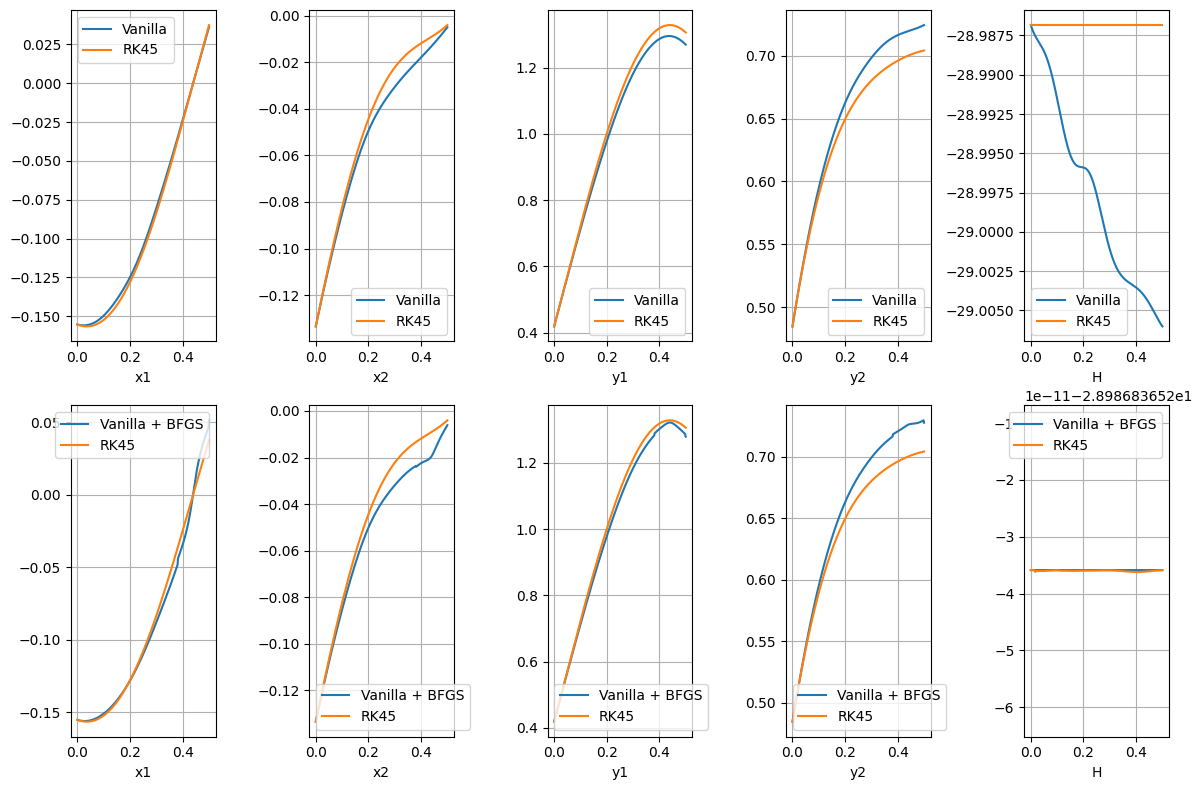

In [35]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, x1)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, x2)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, y1)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, y2)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, H)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, x1_min)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, x2_min)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, y1_min)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, y2_min)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])

plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, H_min)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla + BFGS','RK45'])


plt.show()

In [36]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)

def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [37]:
class ClosestPoint(nn.Module):
    
    @nn.compact
    def __call__(self, inputs):

        x = inputs[0]
        H_0 = inputs[1]

        z_min = find_min_H(x, H_0)
    
        return z_min

In [38]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:4]
    H_0 = u[:, 4:]

    u = u[:, :4]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t, y2])

    z = jnp.column_stack([x1, x2, y1, y2])
    z = ClosestPoint()([z, H_0])

    x1 = z[:, :1]
    x2 = z[:, 1:2]
    y1 = z[:, 2:3]
    y2 = z[:, 3:]
      
    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [39]:
# class CDeepONet(nn.Module):

#   t0: float
#   tfinal: float
#   layers: int
#   units: int

#   @nn.compact
#   def __call__(self, t, z0):

#     if z0.ndim == 1:
#       z0 = jnp.reshape(z0, (1,-1))


#     H_0 = z0[:, 4:]
#     z0 = z0[:, :4]

#     t = jnp.reshape(t, (-1,1))

#     b = Normalize(self.t0, self.tfinal)(t)

#     trunk_net = MLP(self.layers, self.units)(b)
#     branch_net = MLP(self.layers, self.units)(z0)

#     trunk_x1 = trunk_net[:,:self.units]
#     trunk_x2 = trunk_net[:,self.units:2*self.units]
#     trunk_y1 = trunk_net[:,2*self.units:3*self.units]
#     trunk_y2 = trunk_net[:,3*self.units:]

#     branch_x1 = branch_net[:,:self.units]
#     branch_x2 = branch_net[:,self.units:2*self.units]
#     branch_y1 = branch_net[:,2*self.units:3*self.units]
#     branch_y2 = branch_net[:,3*self.units:]

#     x1 = CombineBranches()(trunk_x1, branch_x1)
#     x2 = CombineBranches()(trunk_x2, branch_x2)
#     y1 = CombineBranches()(trunk_y1, branch_y1)
#     y2 = CombineBranches()(trunk_y2, branch_y2)

#     x1 = HardConstraint(self.t0, self.tfinal, z0[:,:1])([t, x1])
#     x2 = HardConstraint(self.t0, self.tfinal, z0[:,1:2])([t, x2])
#     y1 = HardConstraint(self.t0, self.tfinal, z0[:,2:3])([t, y1])
#     y2 = HardConstraint(self.t0, self.tfinal, z0[:,3:])([t, y2])

#     z = jnp.column_stack([x1, x2, y1, y2])

#     z = ClosestPoint()([z, H_0])
      
#     x1 = jnp.reshape(z[:,:1], (-1,))
#     x2 = jnp.reshape(z[:,1:2], (-1,))
#     y1 = jnp.reshape(z[:,2:3], (-1,))
#     y2 = jnp.reshape(z[:,3:], (-1,))

#     return x1, x2, y1, y2

In [40]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=units_num)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), jnp.ones((10,1)), jnp.ones((10,5)))

Cparams = copy.deepcopy(params)

Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

19960


In [41]:
tree_info, shapes, Cparams_flat = flatten_pytree(Cparams)

In [42]:
@partial(jax.jit, static_argnums=(2,))
def cw_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def cw(t, z, component, params):
  return jax.vmap(cw_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def cw_t(t, z, component, params):
  return jax.vmap(jax.grad(cw_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def closs(params, t, z):

    diff_loss_w = 1.0
    H_loss_w = 0.0

    H_vals = z[:, -1]

    x1 = w(t, z, 0, params)
    x2 = w(t, z, 1, params)
    y1 = w(t, z, 2, params)
    y2 = w(t, z, 3, params)
    
    x1_t = w_t(t, z, 0, params)
    x2_t = w_t(t, z, 1, params)
    y1_t = w_t(t, z, 2, params)
    y2_t = w_t(t, z, 3, params)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)
 
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    H_loss = jnp.mean((H - H_vals)**2)

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss

@jax.jit
def ctrain_step(params, pdes, z):
    t = pdes[:,0]
    return jax.value_and_grad(closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [43]:
def ctrain_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 1
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:
        
      loss, grads = ctrain_step(params, des_batch.numpy(), z_batch.numpy())
                   
      params, opt_state = coptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [44]:
# epochs = 2
# Cparams, loss = ctrain_network(Cparams, de_points, zsensors, epochs)

In [45]:
# cx1 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 0, params)
# cx2 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 1, params)
# cy1 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 2, params)
# cy2 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 3, params)

# cH = (m2*l2**2*cy1**2 + (m1+m2)*l1**2*cy2**2 - 2*m2*l1*l2*cy1*cy2*np.cos(cx1-cx2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(cx1-cx2)**2))-(m1+m2)*grav*l1*np.cos(cx1)-m2*grav*l2*np.cos(cx2)

In [46]:
# fig = plt.figure(figsize=(12, 8))

# plt.subplot(3, 5, 1)
# plt.tight_layout()
# plt.plot(t, x1)
# plt.plot(t, x1rk)
# plt.xlabel("x1")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 2)
# plt.tight_layout()
# plt.plot(t, x2)
# plt.plot(t, x2rk)
# plt.xlabel("x2")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 3)
# plt.tight_layout()
# plt.plot(t, y1)
# plt.plot(t, y1rk)
# plt.xlabel("y1")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 4)
# plt.tight_layout()
# plt.plot(t, y2)
# plt.plot(t, y2rk)
# plt.xlabel("y2")
# plt.grid()
# plt.legend(['Vanilla','RK45'])


# plt.subplot(3, 5, 5)
# plt.tight_layout()
# plt.plot(t, H)
# plt.plot(t, Hrk)
# plt.xlabel("H")
# plt.grid()
# plt.legend(['Vanilla','RK45'])

# plt.subplot(3, 5, 6)
# plt.tight_layout()
# plt.plot(t, x1_min)
# plt.plot(t, x1rk)
# plt.xlabel("x1")
# plt.grid()
# plt.legend(['Vanilla + BFGS','RK45'])

# plt.subplot(3, 5, 7)
# plt.tight_layout()
# plt.plot(t, x2_min)
# plt.plot(t, x2rk)
# plt.xlabel("x2")
# plt.grid()
# plt.legend(['Vanilla + BFGS','RK45'])

# plt.subplot(3, 5, 8)
# plt.tight_layout()
# plt.plot(t, y1_min)
# plt.plot(t, y1rk)
# plt.xlabel("y1")
# plt.grid()
# plt.legend(['Vanilla + BFGS','RK45'])

# plt.subplot(3, 5, 9)
# plt.tight_layout()
# plt.plot(t, y2_min)
# plt.plot(t, y2rk)
# plt.xlabel("y2")
# plt.grid()
# plt.legend(['Vanilla + BFGS','RK45'])

# plt.subplot(3, 5, 10)
# plt.tight_layout()
# plt.plot(t, H_min)
# plt.plot(t, Hrk)
# plt.xlabel("H")
# plt.grid()
# plt.legend(['Vanilla + BFGS','RK45'])

# plt.subplot(3, 5, 11)
# plt.tight_layout()
# plt.plot(t, cx1)
# plt.plot(t, x1rk)
# plt.xlabel("x1")
# plt.grid()
# plt.legend(['Vanilla + Cons','RK45'])

# plt.subplot(3, 5, 12)
# plt.tight_layout()
# plt.plot(t, cx2)
# plt.plot(t, x2rk)
# plt.xlabel("x2")
# plt.grid()
# plt.legend(['Vanilla + Cons','RK45'])

# plt.subplot(3, 5, 13)
# plt.tight_layout()
# plt.plot(t, cy1)
# plt.plot(t, y1rk)
# plt.xlabel("y1")
# plt.grid()
# plt.legend(['Vanilla + Cons','RK45'])

# plt.subplot(3, 5, 14)
# plt.tight_layout()
# plt.plot(t, cy2)
# plt.plot(t, y2rk)
# plt.xlabel("y2")
# plt.grid()
# plt.legend(['Vanilla + Cons','RK45'])

# plt.subplot(3, 5, 15)
# plt.tight_layout()
# plt.plot(t, cH)
# plt.plot(t, Hrk)
# plt.xlabel("H")
# plt.grid()
# plt.legend(['Vanilla + Cons','RK45'])

# plt.show()

In [47]:
@jax.jit
def loss_fun(params, t, z):
    
    return closs(params, t, z)


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun)(params, t, z)

In [48]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [49]:
@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.1
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        cond = jnp.logical_and(cond1, cond2)

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [50]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s
    

In [51]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes[:,0] 
    
    losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        losses.append(loss_fun(paramsn, t, z))
        
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    return paramsn, losses

In [52]:
# epochs = 1000
# Cparams, loss_lbfgs = lbfgs(Cparams, de_points, zsensors, epochs)

In [53]:
def ctrain_network_lbfgs(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 1
  batch_size = len(des)//nr_batches

  ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:
        
      params, loss = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 5)     
      epoch_loss[i] += loss[-1]

    epoch_loss[i] /= batch_size

    if i % 10 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [54]:
epochs = 100
Cparams, loss_lbfgs = ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

Loss in epoch 0: 7.759975262081364e-06
Loss in epoch 10: 7.347101099237415e-06
Loss in epoch 20: 7.303079677321595e-06
Loss in epoch 30: 7.281327054842142e-06
Loss in epoch 40: 7.267526867882867e-06
Loss in epoch 50: 7.257229604506495e-06
Loss in epoch 60: 7.248897549903121e-06
Loss in epoch 70: 7.241761358926294e-06
Loss in epoch 80: 7.235402950674246e-06
Loss in epoch 90: 7.2296856604227e-06


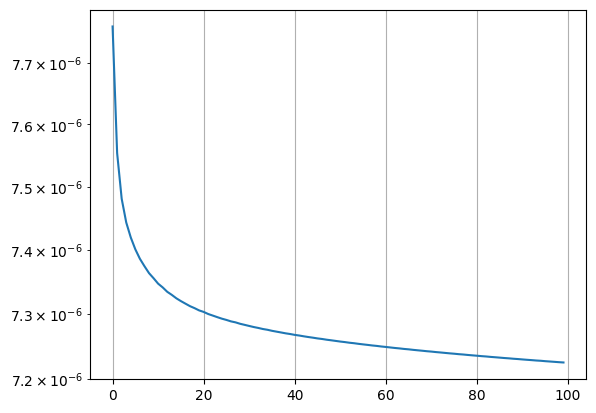

In [55]:
plt.semilogy(loss_lbfgs)
plt.grid()

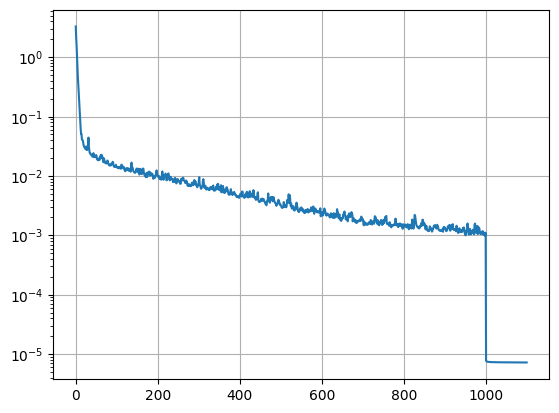

In [56]:
total_loss = np.concatenate((loss_adam, loss_lbfgs))
plt.semilogy(total_loss)
plt.grid()

In [57]:
cx1 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 0, Cparams)
cx2 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 1, Cparams)
cy1 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 2, Cparams)
cy2 = jax.vmap(cw_model, [0, 0, None, None])(t, z_init_H, 3, Cparams)

cH = (m2*l2**2*cy1**2 + (m1+m2)*l1**2*cy2**2 - 2*m2*l1*l2*cy1*cy2*np.cos(cx1-cx2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(cx1-cx2)**2))-(m1+m2)*grav*l1*np.cos(cx1)-m2*grav*l2*np.cos(cx2)

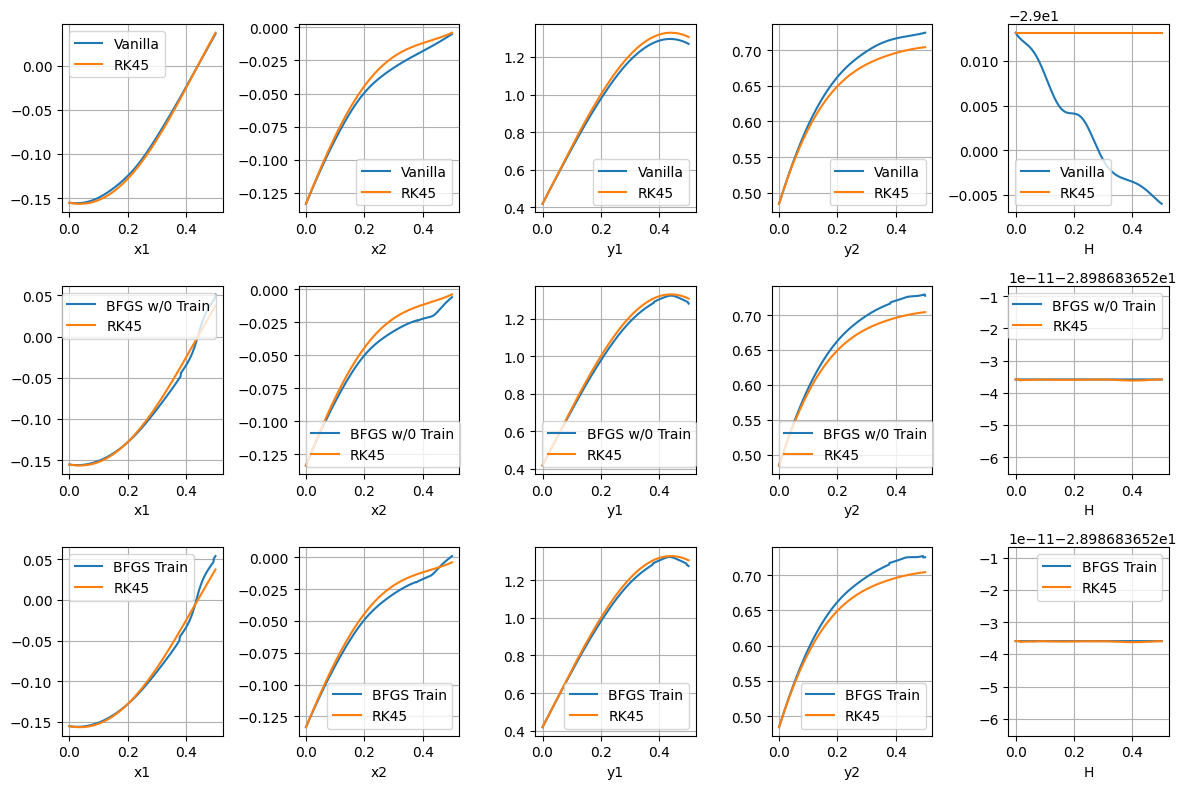

In [58]:
fig = plt.figure(figsize=(12, 8))

plt.subplot(3, 5, 1)
plt.tight_layout()
plt.plot(t, x1)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 2)
plt.tight_layout()
plt.plot(t, x2)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 3)
plt.tight_layout()
plt.plot(t, y1)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 4)
plt.tight_layout()
plt.plot(t, y2)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla','RK45'])


plt.subplot(3, 5, 5)
plt.tight_layout()
plt.plot(t, H)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(3, 5, 6)
plt.tight_layout()
plt.plot(t, x1_min)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['BFGS w/0 Train','RK45'])

plt.subplot(3, 5, 7)
plt.tight_layout()
plt.plot(t, x2_min)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['BFGS w/0 Train','RK45'])

plt.subplot(3, 5, 8)
plt.tight_layout()
plt.plot(t, y1_min)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['BFGS w/0 Train','RK45'])

plt.subplot(3, 5, 9)
plt.tight_layout()
plt.plot(t, y2_min)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['BFGS w/0 Train','RK45'])

plt.subplot(3, 5, 10)
plt.tight_layout()
plt.plot(t, H_min)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['BFGS w/0 Train','RK45'])

plt.subplot(3, 5, 11)
plt.tight_layout()
plt.plot(t, cx1)
plt.plot(t, x1rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['BFGS Train','RK45'])

plt.subplot(3, 5, 12)
plt.tight_layout()
plt.plot(t, cx2)
plt.plot(t, x2rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['BFGS Train','RK45'])

plt.subplot(3, 5, 13)
plt.tight_layout()
plt.plot(t, cy1)
plt.plot(t, y1rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['BFGS Train','RK45'])

plt.subplot(3, 5, 14)
plt.tight_layout()
plt.plot(t, cy2)
plt.plot(t, y2rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['BFGS Train','RK45'])

plt.subplot(3, 5, 15)
plt.tight_layout()
plt.plot(t, cH)
plt.plot(t, Hrk)
plt.xlabel("H")
plt.grid()
plt.legend(['BFGS Train','RK45'])

plt.show()

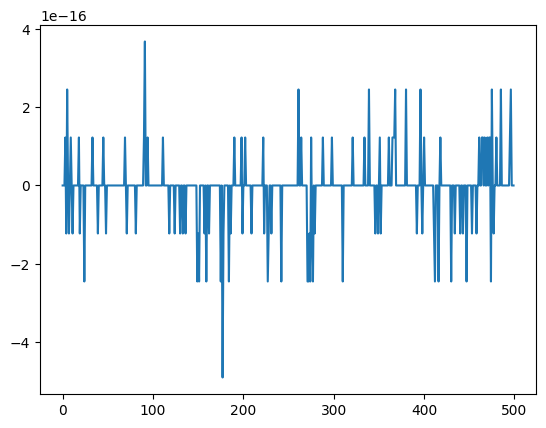

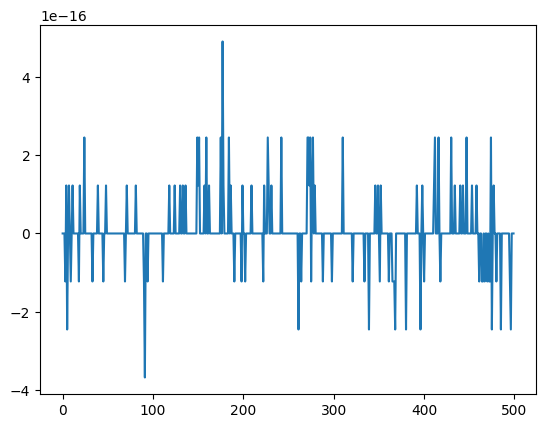

In [59]:
plt.plot((H_min-cH)/H_min)
plt.show()

plt.plot((cH-H_min)/cH)
plt.show()

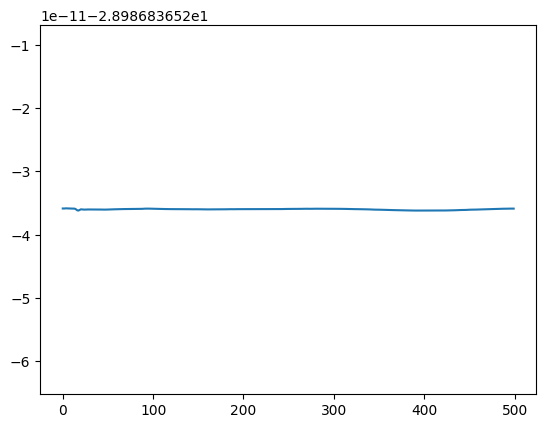

In [60]:
plt.plot(Hrk)
